In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [41]:
df_temperatura = pd.read_csv('celsius_a_fahrenheit.csv')
print(df_temperatura.head())

   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0


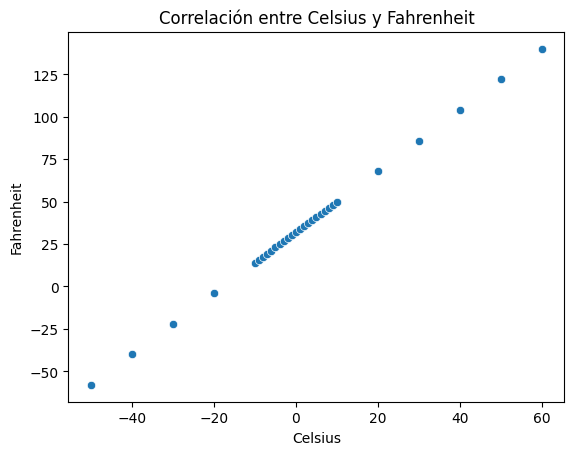

In [42]:
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.title('Correlación entre Celsius y Fahrenheit')
plt.xlabel('Celsius')
plt.ylabel('Fahrenheit')
plt.show()

In [43]:
X_train = df_temperatura['Celsius'].values
Y_train = df_temperatura['Fahrenheit'].values

In [44]:
print("=== MODELO 1: 1 capa densa ===")
print("Creando el modelo...")
model1 = tf.keras.Sequential()
model1.add(tf.keras.layers.Input(shape=(1,)))
model1.add(tf.keras.layers.Dense(units=1))

print("Compilando el modelo...")
model1.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

print("Entrenando el modelo...")
hist1 = model1.fit(X_train, Y_train, epochs=100, verbose=False)
print("¡Entrenamiento terminado!")

=== MODELO 1: 1 capa densa ===
Creando el modelo...
Compilando el modelo...
Entrenando el modelo...
¡Entrenamiento terminado!


In [45]:
print("=== MODELO 2: 3 capas (2 ocultas + salida) ===")
print("Creando el modelo...")
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida  = tf.keras.layers.Dense(units=1)

model2 = tf.keras.Sequential([oculta1, oculta2, salida])

print("Compilando el modelo...")
model2.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

print("Entrenando el modelo...")
hist2 = model2.fit(X_train, Y_train, epochs=100, verbose=False)
print("¡Entrenamiento terminado!")

=== MODELO 2: 3 capas (2 ocultas + salida) ===
Creando el modelo...
Compilando el modelo...
Entrenando el modelo...


/opt/anaconda3/envs/mledu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


¡Entrenamiento terminado!


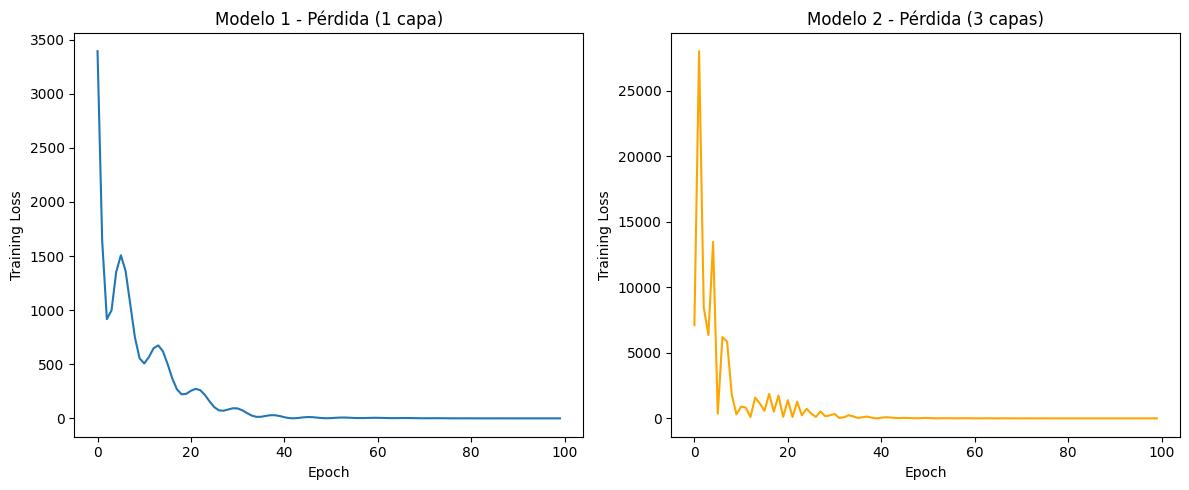

In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist1.history['loss'])
plt.title('Modelo 1 - Pérdida (1 capa)')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(hist2.history['loss'], color='orange')
plt.title('Modelo 2 - Pérdida (3 capas)')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')

plt.tight_layout()
plt.show()

In [47]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])

Temp_F_modelo1 = model1.predict(Temp_C_array)
Temp_F_modelo2 = model2.predict(Temp_C_array)
Temp_F_formula = (9/5) * Temp_C + 32

print(f"Temperatura ingresada:       {Temp_C} °C")
print(f"Predicción Modelo 1 (1 capa): {Temp_F_modelo1[0][0]:.4f} °F")
print(f"Predicción Modelo 2 (3 capas): {Temp_F_modelo2[0][0]:.4f} °F")
print(f"Temperatura real (fórmula):   {Temp_F_formula} °F")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Temperatura ingresada:       100 °C
Predicción Modelo 1 (1 capa): 211.3351 °F
Predicción Modelo 2 (3 capas): 211.0035 °F
Temperatura real (fórmula):   212.0 °F


In [48]:
print("Pesos oculta1:", oculta1.get_weights())
print("Pesos oculta2:", oculta2.get_weights())
print("Pesos salida:", salida.get_weights())

Pesos oculta1: [array([[ 0.27553743,  0.6242443 , -0.41697004]], dtype=float32), array([10.672649 ,  8.329555 , -7.6245813], dtype=float32)]
Pesos oculta2: [array([[-3.2839556 ,  2.5994346 , -0.9605557 ],
       [ 2.5405273 , -2.4017487 , -0.5394123 ],
       [ 0.27155796, -2.7286682 ,  0.55990154]], dtype=float32), array([  8.127029 , -12.4783535,   7.5739694], dtype=float32)]
Pesos salida: [array([[ 0.8970826 ],
       [ 0.36794165],
       [-1.3802862 ]], dtype=float32), array([17.102427], dtype=float32)]


## Optimizadores

Adam (el que usamos): combina lo mejor de SGD y RMSProp, adapta el learning rate por parámetro. Es el más estable y converge rápido, por eso es el más popular.
SGD (Stochastic Gradient Descent): el más simple, actualiza los pesos con una tasa fija. Con nuestro modelo bajaría más lento y la curva de pérdida sería menos suave, necesitaría más epochs.
RMSProp: adapta el learning rate según el historial reciente de gradientes. Funcionaría bien aquí también, pero con más oscilaciones que Adam al inicio.

## Función de pérdida
mean_squared_error es importante porque penaliza fuertemente los errores grandes (los eleva al cuadrado), lo que obliga al modelo a evitar predicciones muy alejadas. Otras opciones:

mean_absolute_error (MAE): mide el error promedio sin elevar al cuadrado, es menos sensible a valores atípicos. El modelo convergiría más lento pero sería más robusto con datos ruidosos.
Huber loss: combinación de MSE y MAE, buen balance entre ambos.

## Epochs suficientes
Mirando las gráficas, el Modelo 1 se estabiliza alrededor del epoch 50 y el Modelo 2 alrededor del epoch 30 (aunque con más caos al inicio). Después de esos puntos la pérdida ya no baja significativamente, así que con ~50 epochs habría sido suficiente para ambos.
    
## Importancia de las epochs
Cada epoch es una pasada completa por todos los datos de entrenamiento. Son importantes porque con pocas epochs el modelo queda underfit (no aprendió suficiente) y con demasiadas puede quedar overfit (memoriza los datos y falla con datos nuevos). El número correcto de epochs es el punto donde la pérdida se estabiliza.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicción Modelo ReLU: 35.6154 °F


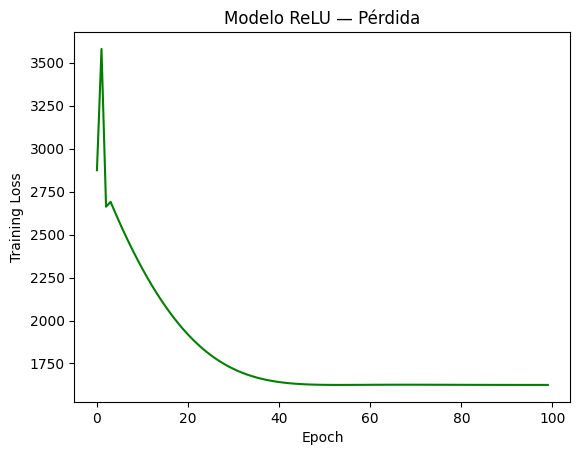

In [ ]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1], activation='relu')
oculta2 = tf.keras.layers.Dense(units=3, activation='relu')
salida  = tf.keras.layers.Dense(units=1) 

model3 = tf.keras.Sequential([oculta1, oculta2, salida])
model3.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')
hist3 = model3.fit(X_train, Y_train, epochs=100, verbose=False)

Temp_F_modelo3 = model3.predict(np.array([[100]]))
print(f"Predicción Modelo ReLU: {Temp_F_modelo3[0][0]:.4f} °F")

plt.plot(hist3.history['loss'], color='green')
plt.title('Modelo ReLU — Pérdida')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()

## Función de activación
Este resultado demuestra perfectamente por qué la función de activación importa y por qué ReLU no es adecuada para este problema de regresión con valores negativos. 